- 4 and 5 Upgrade and Downgrade Analysis

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Set style for plots
plt.style.use('seaborn')
%matplotlib inline

C:\Users\rohan\AppData\Local\Temp\ipykernel_5668\1040132399.py:2: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


In [3]:
# Load data (replace with your actual file paths)
lio_subs = pd.read_csv('Jotstar CSV files/subscribers.csv')
jotstar_subs = pd.read_csv('LioCinema CSV files/subscribers.csv')

In [4]:
lio_subs.head()

,user_id,age_group,city_tier,subscription_date,subscription_plan,last_active_date,plan_change_date,new_subscription_plan
0,UIDJS0000751588f,18-24,Tier 1,2024-06-10,Premium,NaN,NaN,NaN
1,UIDJS000093eeb86,18-24,Tier 1,2024-11-09,Free,NaN,NaN,NaN
2,UIDJS00010d7fa1e,25-34,Tier 1,2024-08-08,Free,NaN,NaN,NaN
3,UIDJS00013411a85,35-44,Tier 2,2024-05-31,VIP,NaN,NaN,NaN
4,UIDJS0003a3f54cf,35-44,Tier 1,2024-09-20,Premium,NaN,NaN,NaN


In [5]:
jotstar_subs.head()

,user_id,age_group,city_tier,subscription_date,subscription_plan,last_active_date,plan_change_date,new_subscription_plan
0,UIDLC00000bea68a,25-34,Tier 3,2024-10-24,Free,NaN,NaN,NaN
1,UIDLC00009202848,18-24,Tier 1,2024-09-18,Basic,NaN,NaN,NaN
2,UIDLC0001086afc3,35-44,Tier 2,2024-03-23,Premium,NaN,2024-04-23,Free
3,UIDLC000186abd93,18-24,Tier 3,2024-09-07,Free,2024-10-23,NaN,NaN
4,UIDLC0002189b09f,18-24,Tier 2,2024-10-07,Premium,NaN,2024-11-07,Free


In [6]:
# Add platform identifiers
lio_subs['platform'] = 'LioCinema'
jotstar_subs['platform'] = 'Jotstar'

In [7]:
# Combine datasets
combined_df = pd.concat([lio_subs, jotstar_subs], ignore_index=True)

In [8]:
# Convert dates to datetime
combined_df['subscription_date'] = pd.to_datetime(combined_df['subscription_date'])
combined_df['plan_change_date'] = pd.to_datetime(combined_df['plan_change_date'])

In [9]:
# Define plan ranks separately for each platform
lio_plan_rank = {'Free': 0, 'Basic': 1, 'Premium': 2}
jotstar_plan_rank = {'Free': 0, 'VIP': 1, 'Premium': 2}

In [10]:
# Apply platform-specific plan ranks
lio_subs['original_plan_rank'] = lio_subs['subscription_plan'].map(lio_plan_rank)
lio_subs['new_plan_rank'] = lio_subs['new_subscription_plan'].map(lio_plan_rank)

In [12]:
jotstar_subs['original_plan_rank'] = jotstar_subs['subscription_plan'].map(jotstar_plan_rank)
jotstar_subs['new_plan_rank'] = jotstar_subs['new_subscription_plan'].map(jotstar_plan_rank)

In [13]:
# Create upgrade flags
lio_subs['upgraded'] = lio_subs['new_plan_rank'] > lio_subs['original_plan_rank']
jotstar_subs['upgraded'] = jotstar_subs['new_plan_rank'] > jotstar_subs['original_plan_rank']

In [14]:
# Combine for visualization
combined_upgrades = pd.concat([lio_subs, jotstar_subs])

# Calculate upgrade rates by platform
upgrade_rates = combined_upgrades.groupby('platform')['upgraded'].mean() * 100
print("Upgrade Rates by Platform (%):")
print(upgrade_rates)

Upgrade Rates by Platform (%):
platform
Jotstar      0.1
LioCinema    1.9
Name: upgraded, dtype: float64


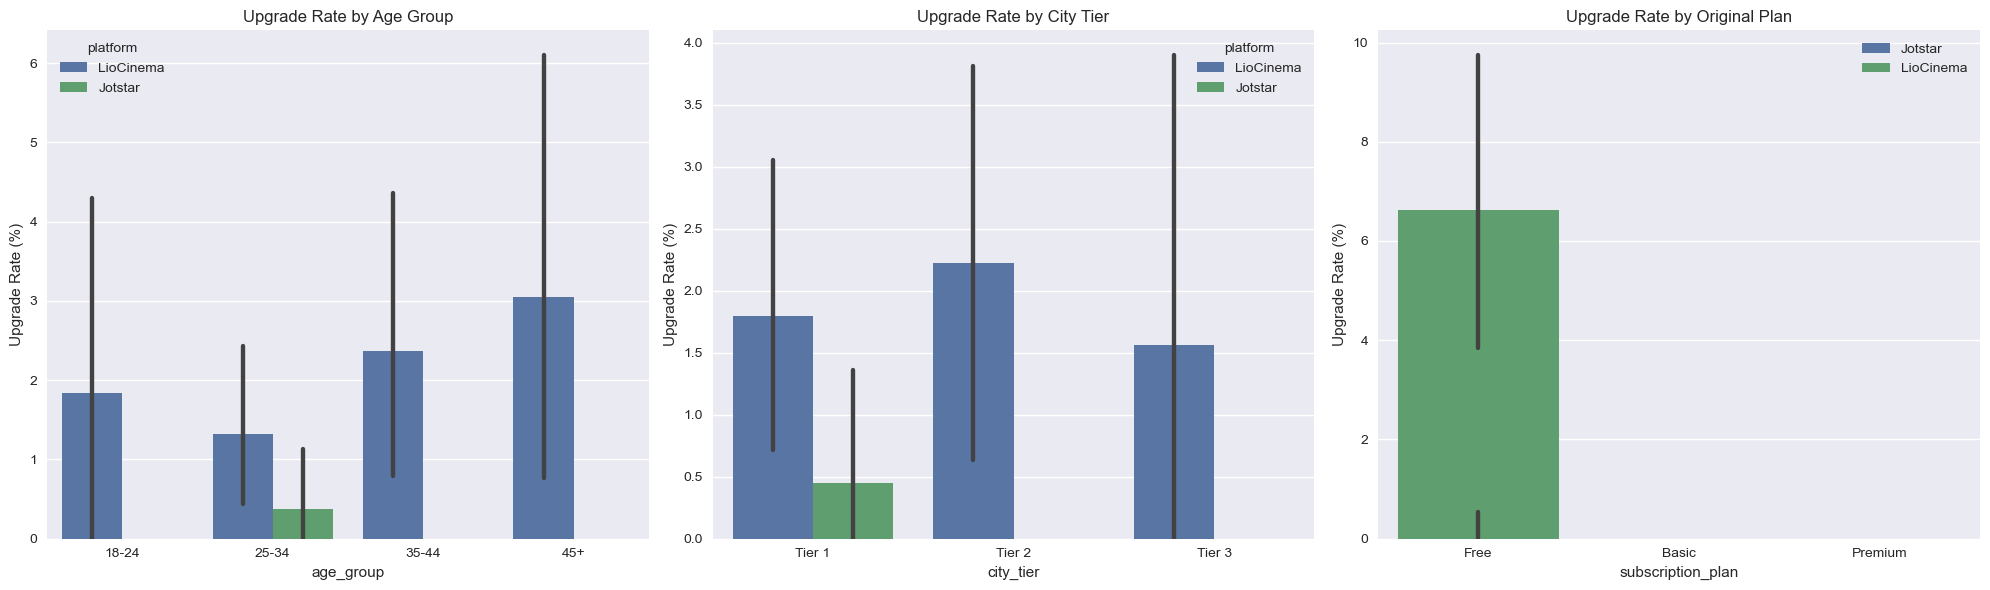

In [16]:
# Visualize upgrade rates by demographics
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# By Age Group
sns.barplot(data=combined_upgrades, x='age_group', y='upgraded', hue='platform', 
            ax=axes[0], estimator=lambda x: np.mean(x)*100)
axes[0].set_title('Upgrade Rate by Age Group')
axes[0].set_ylabel('Upgrade Rate (%)')

# By City Tier
sns.barplot(data=combined_upgrades, x='city_tier', y='upgraded', hue='platform', 
            ax=axes[1], estimator=lambda x: np.mean(x)*100)
axes[1].set_title('Upgrade Rate by City Tier')
axes[1].set_ylabel('Upgrade Rate (%)')

# By Original Plan (platform-specific)
axes[2].set_title('Upgrade Rate by Original Plan')
for i, (platform, df) in enumerate(combined_upgrades.groupby('platform')):
    plan_order = lio_plan_rank.keys() if platform == 'LioCinema' else jotstar_plan_rank.keys()
    sns.barplot(data=df, x='subscription_plan', y='upgraded', 
                order=plan_order, color=sns.color_palette()[i],
                ax=axes[2], estimator=lambda x: np.mean(x)*100, 
                label=platform)
axes[2].set_ylabel('Upgrade Rate (%)')
axes[2].legend()

plt.tight_layout()
plt.show()
